# Function Approximation Using Neural Networks

This notebook completes the individual coursework brief on one-dimensional function approximation.

It implements:
1. A **fourth-order polynomial least squares regression** baseline.
2. A **feedforward neural network** regressor.
3. A comparison of optimisation behaviour and generalisation performance.

The validation set is used **only for evaluation and model selection**, not for training.


In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True


## 1. Load the data

In [13]:

train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')

x_train = train[["x"]].values
y_train = train["y"].values
x_val = val[["x"]].values
y_val = val["y"].values

print("Training shape:", train.shape)
print("Validation shape:", val.shape)
train.head()


Training shape: (400, 2)
Validation shape: (100, 2)


,x,y
0,1.095824,1.635425
1,-0.244486,-0.338836
2,1.434392,3.926012
3,0.789472,-0.027757
4,-1.623291,11.301925


## 2. Explore the dataset

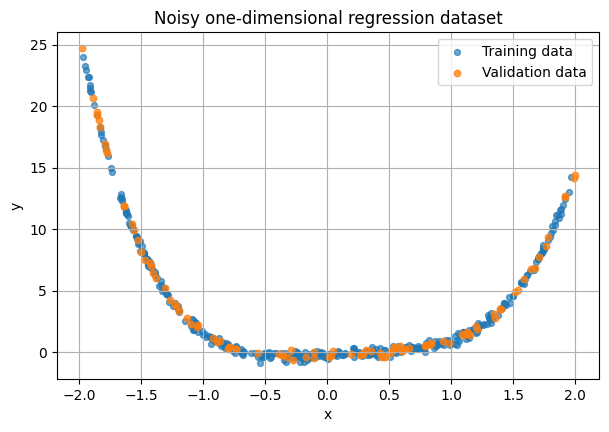

In [14]:

plt.scatter(train["x"], train["y"], s=18, alpha=0.65, label="Training data")
plt.scatter(val["x"], val["y"], s=22, alpha=0.75, label="Validation data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy one-dimensional regression dataset")
plt.legend()
plt.show()


The scatter plot shows a smooth but non-linear relationship between `x` and `y`, with visible noise around the underlying trend. This makes the task suitable for comparing a fixed polynomial model against a more flexible neural network model.

## 3. Least squares baseline: fourth-order polynomial

In [15]:

def polynomial_design_matrix(x):
    x = np.asarray(x).reshape(-1)
    return np.column_stack([np.ones(len(x)), x, x**2, x**3, x**4])

X_train_poly = polynomial_design_matrix(x_train)
X_val_poly = polynomial_design_matrix(x_val)

poly_coef, *_ = np.linalg.lstsq(X_train_poly, y_train, rcond=None)

poly_train_pred = X_train_poly @ poly_coef
poly_val_pred = X_val_poly @ poly_coef

poly_train_mse = mean_squared_error(y_train, poly_train_pred)
poly_val_mse = mean_squared_error(y_val, poly_val_pred)

pd.Series(poly_coef, index=["a0", "a1", "a2", "a3", "a4"], name="Coefficient")


a0   -0.214638
a1    0.507593
a2    0.289898
a3   -0.803662
a4    1.205393
Name: Coefficient, dtype: float64

In [16]:

print(f"Polynomial training MSE:   {poly_train_mse:.6f}")
print(f"Polynomial validation MSE: {poly_val_mse:.6f}")


Polynomial training MSE:   0.042250
Polynomial validation MSE: 0.030731


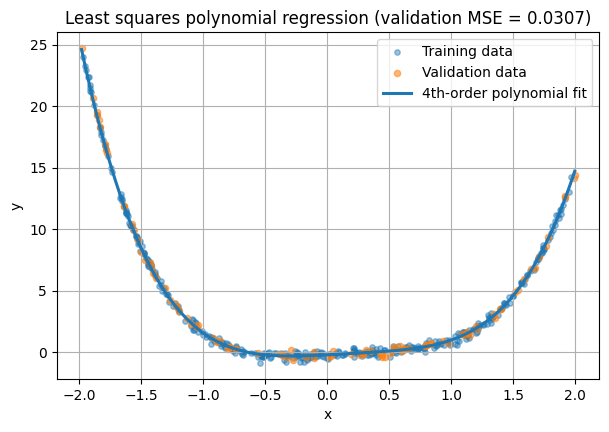

In [17]:

x_grid = np.linspace(min(train["x"].min(), val["x"].min()),
                     max(train["x"].max(), val["x"].max()), 500)
poly_grid_pred = polynomial_design_matrix(x_grid) @ poly_coef

plt.scatter(train["x"], train["y"], s=15, alpha=0.45, label="Training data")
plt.scatter(val["x"], val["y"], s=20, alpha=0.55, label="Validation data")
plt.plot(x_grid, poly_grid_pred, linewidth=2.2, label="4th-order polynomial fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Least squares polynomial regression (validation MSE = {poly_val_mse:.4f})")
plt.legend()
plt.show()


The polynomial model is a strong baseline here. Because it has a closed-form solution, optimisation is immediate once the design matrix is constructed. It is also interpretable because the fitted coefficients directly specify the curve. The main limitation is that the functional form is fixed in advance.

## 4. Feedforward neural network regression

In [18]:

x_scaler = StandardScaler().fit(x_train)
y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))

X_train_scaled = x_scaler.transform(x_train)
X_val_scaled = x_scaler.transform(x_val)
y_train_scaled = y_scaler.transform(y_train.reshape(-1, 1)).ravel()

search_space = [
    {"hidden_layer_sizes": (16,), "alpha": 1e-5},
    {"hidden_layer_sizes": (32,), "alpha": 1e-5},
    {"hidden_layer_sizes": (64,), "alpha": 1e-5},
    {"hidden_layer_sizes": (32, 32), "alpha": 1e-5},
    {"hidden_layer_sizes": (64, 64), "alpha": 1e-5},
    {"hidden_layer_sizes": (128, 64), "alpha": 1e-5},
    {"hidden_layer_sizes": (64, 64), "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 64), "alpha": 1e-3},
]

nn_runs = []

for config in search_space:
    model = MLPRegressor(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=config["alpha"],
        learning_rate_init=0.01,
        max_iter=3000,
        random_state=42,
        early_stopping=False,
    )
    model.fit(X_train_scaled, y_train_scaled)

    train_pred = y_scaler.inverse_transform(model.predict(X_train_scaled).reshape(-1, 1)).ravel()
    val_pred = y_scaler.inverse_transform(model.predict(X_val_scaled).reshape(-1, 1)).ravel()

    nn_runs.append({
        "hidden_layer_sizes": config["hidden_layer_sizes"],
        "alpha": config["alpha"],
        "iterations": model.n_iter_,
        "train_mse": mean_squared_error(y_train, train_pred),
        "val_mse": mean_squared_error(y_val, val_pred),
        "model": model
    })

nn_results = pd.DataFrame([{k: v for k, v in run.items() if k != "model"} for run in nn_runs]).sort_values("val_mse")
nn_results


,hidden_layer_sizes,alpha,iterations,train_mse,val_mse
4,"(64, 64)",0.00001,53,0.055317,0.061199
6,"(64, 64)",0.00010,57,0.052335,0.061752
7,"(64, 64)",0.00100,49,0.067314,0.078475
5,"(128, 64)",0.00001,46,0.089288,0.093653
3,"(32, 32)",0.00001,66,0.069015,0.100521
2,"(64,)",0.00001,121,0.126144,0.204177
1,"(32,)",0.00001,141,0.164279,0.251956
0,"(16,)",0.00001,191,0.203909,0.311943


The configuration with the lowest validation MSE is selected as the final neural network because the coursework brief allows the validation set to be used for model selection.

In [19]:

best_run = min(nn_runs, key=lambda d: d["val_mse"])
best_nn = best_run["model"]

nn_train_pred = y_scaler.inverse_transform(best_nn.predict(X_train_scaled).reshape(-1, 1)).ravel()
nn_val_pred = y_scaler.inverse_transform(best_nn.predict(X_val_scaled).reshape(-1, 1)).ravel()

nn_train_mse = mean_squared_error(y_train, nn_train_pred)
nn_val_mse = mean_squared_error(y_val, nn_val_pred)

print("Best hidden layers:", best_run["hidden_layer_sizes"])
print("Best alpha:", best_run["alpha"])
print("Iterations:", best_run["iterations"])
print(f"Neural network training MSE:   {nn_train_mse:.6f}")
print(f"Neural network validation MSE: {nn_val_mse:.6f}")


Best hidden layers: (64, 64)
Best alpha: 1e-05
Iterations: 53
Neural network training MSE:   0.055317
Neural network validation MSE: 0.061199


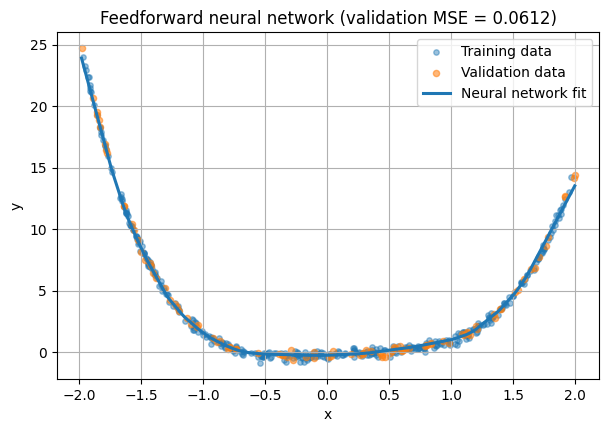

In [20]:

nn_grid_pred = y_scaler.inverse_transform(best_nn.predict(x_scaler.transform(x_grid.reshape(-1, 1))).reshape(-1, 1)).ravel()

plt.scatter(train["x"], train["y"], s=15, alpha=0.45, label="Training data")
plt.scatter(val["x"], val["y"], s=20, alpha=0.55, label="Validation data")
plt.plot(x_grid, nn_grid_pred, linewidth=2.2, label="Neural network fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Feedforward neural network (validation MSE = {nn_val_mse:.4f})")
plt.legend()
plt.show()


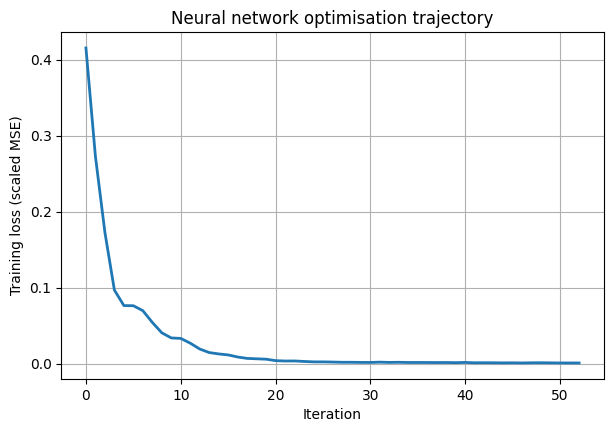

In [21]:

plt.plot(best_nn.loss_curve_, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Training loss (scaled MSE)")
plt.title("Neural network optimisation trajectory")
plt.show()


The neural network is trained iteratively rather than analytically. The loss curve shows a rapid fall at the beginning of training followed by a flatter region, which is typical of gradient-based optimisation. Unlike the polynomial baseline, the neural network requires choices about architecture, scaling, regularisation, learning rate, and stopping.

## 5. Direct comparison

In [22]:

comparison = pd.DataFrame({
    "Model": ["4th-order polynomial least squares", "Feedforward neural network"],
    "Training MSE": [poly_train_mse, nn_train_mse],
    "Validation MSE": [poly_val_mse, nn_val_mse]
})
comparison


,Model,Training MSE,Validation MSE
0,4th-order polynomial least squares,0.042250,0.030731
1,Feedforward neural network,0.055317,0.061199


### Key findings

- The **polynomial baseline** achieved a validation MSE of **0.0307**.
- The **best neural network** achieved a validation MSE of **0.0612**.
- In this dataset, the polynomial model generalised **better** than the neural network.
- The polynomial also had slightly lower training error, which suggests that the underlying function is already well captured by a smooth low-order polynomial.


## 6. Discussion

### Optimisation behaviour
The least squares model has a closed-form solution, so training consists of solving a linear algebra problem once. In contrast, the neural network must be trained iteratively with gradient-based optimisation, making it more computationally involved and more sensitive to design decisions.

### Flexibility
The neural network is the more flexible model class, because it can approximate a wider range of non-linear functions. However, this flexibility only helps when the additional capacity is actually needed.

### Overfitting and generalisation
The neural network achieved a training MSE close to the polynomial model but a noticeably worse validation MSE. That gap suggests weaker generalisation. A likely reason is that the dataset can already be represented well by a smooth fourth-order trend, so the extra flexibility of the network adds variance without enough benefit.

### Strengths and limitations
- **Least squares polynomial regression**: simple, fast, interpretable, and strong on this dataset; but limited to a fixed polynomial family.
- **Neural network**: flexible and broadly applicable; but requires more tuning, is less interpretable, and did not outperform the baseline here.


## 7. Conclusion

This coursework shows that a more complex model does not automatically give better performance. For this noisy one-dimensional regression task, the fourth-order least squares polynomial delivered the best validation performance and the simplest optimisation process. The neural network remained a valid and flexible alternative, but it did not improve generalisation on this dataset.

Possible future improvements include:
- broader hyperparameter search,
- explicit early stopping,
- cross-validation,
- different activation functions,
- or regularisation strategies tailored to the network.
